# Credit Card Fraud Detection — Exploratory Data Analysis
**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Task:** Binary Classification (fraud vs. legitimate)  
**Author:** Data Mining Course Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FIGSIZE = (14, 6)
SAVE_DIR = '../results/figures/'

import os
os.makedirs(SAVE_DIR, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Dataset

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## 2. Basic Statistics

In [4]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Time,284807.000000,94813.859575,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.000000,0.000000,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.000000,0.000000,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.000000,-0.000000,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.000000,0.000000,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.000000,0.000000,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.000000,0.000000,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.000000,-0.000000,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.000000,0.000000,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.000000,-0.000000,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 3. Missing Values & Duplicates

In [5]:
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')

Missing values : 0


Duplicate rows : 1081


## 4. Class Distribution (Imbalance Analysis)

Class distribution:
        Count  Percentage
Class                    
0      284315     99.8273
1         492      0.1727


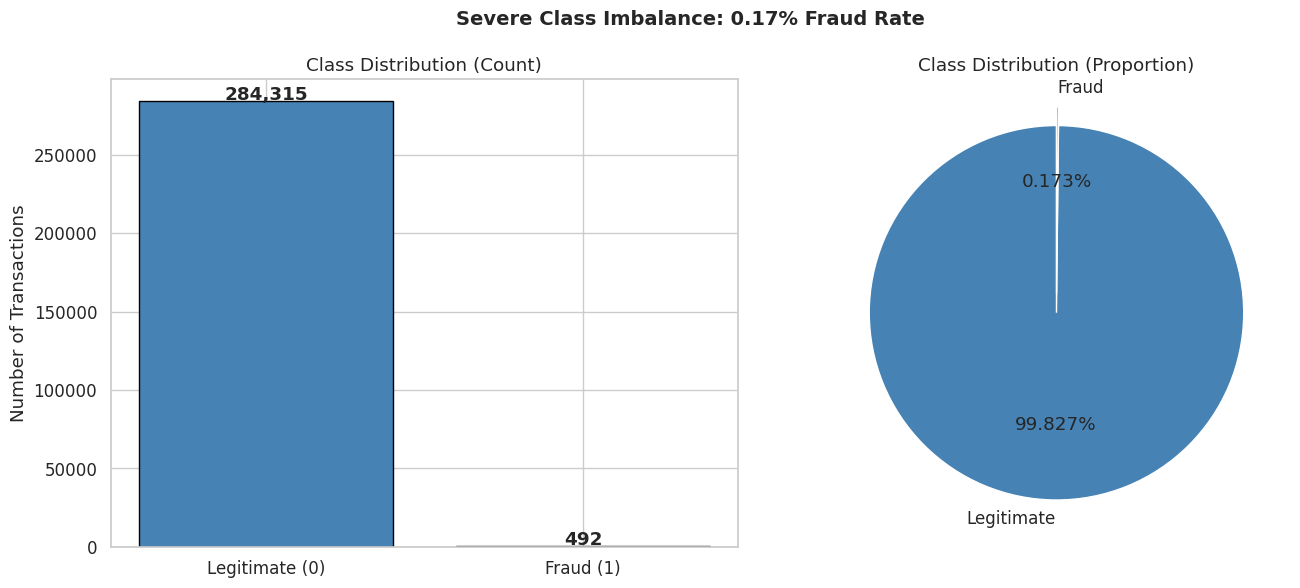

In [6]:
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print('Class distribution:')
print(pd.DataFrame({'Count': class_counts, 'Percentage': class_pct.round(4)}))

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

# Bar chart
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue', 'tomato'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (Proportion)')

plt.suptitle('Severe Class Imbalance: 0.17% Fraud Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Distributions: Amount & Time

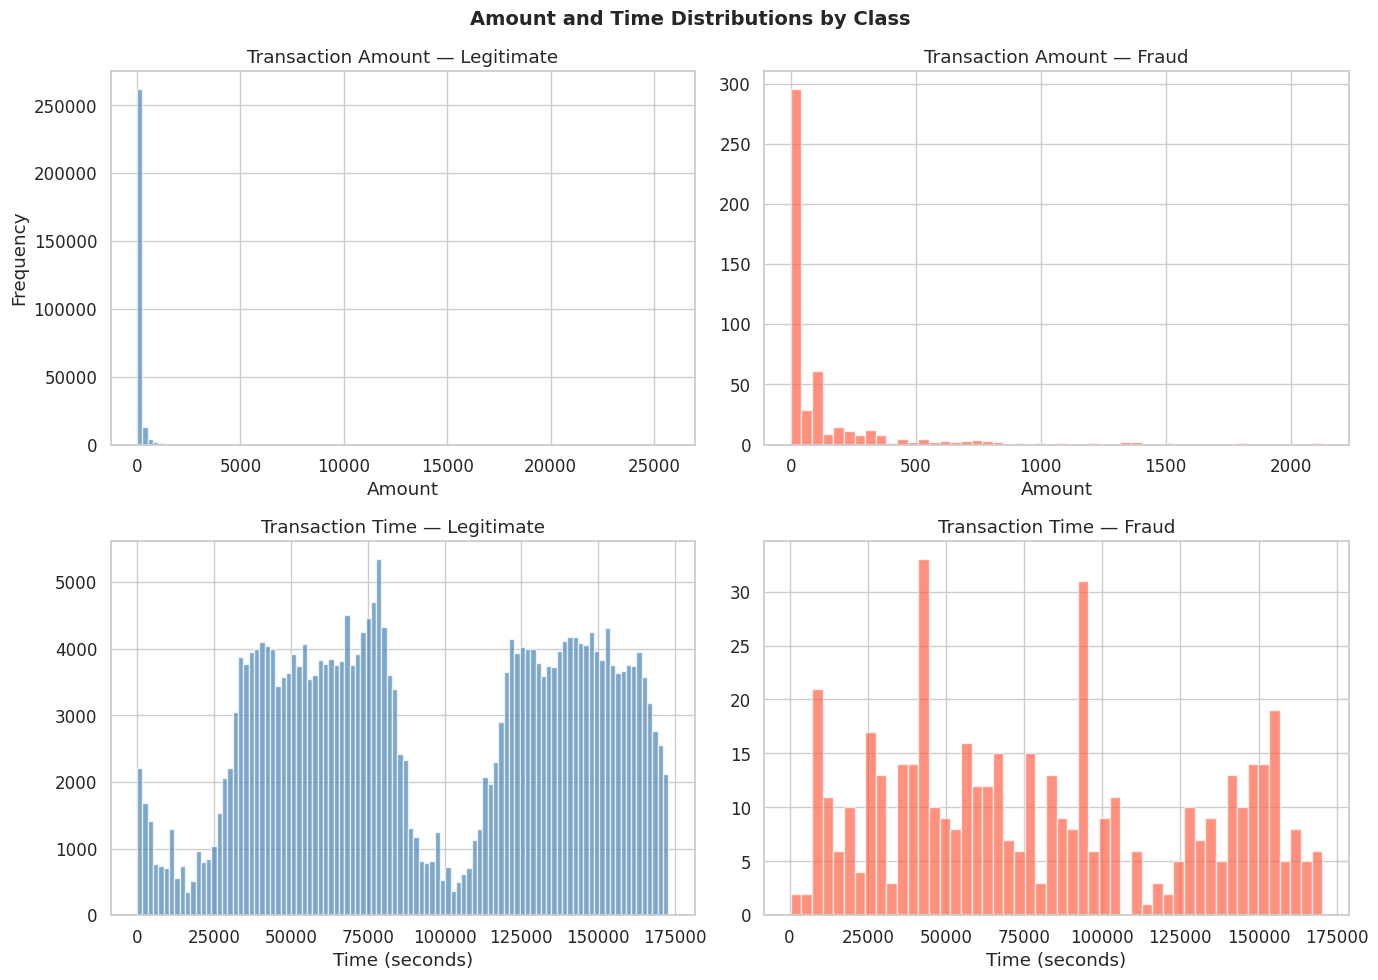

Amount stats by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution
axes[0,0].hist(df[df['Class']==0]['Amount'], bins=100, color='steelblue', alpha=0.7, label='Legitimate')
axes[0,0].set_title('Transaction Amount — Legitimate')
axes[0,0].set_xlabel('Amount'); axes[0,0].set_ylabel('Frequency')

axes[0,1].hist(df[df['Class']==1]['Amount'], bins=50, color='tomato', alpha=0.7, label='Fraud')
axes[0,1].set_title('Transaction Amount — Fraud')
axes[0,1].set_xlabel('Amount')

# Time distribution
axes[1,0].hist(df[df['Class']==0]['Time'], bins=100, color='steelblue', alpha=0.7)
axes[1,0].set_title('Transaction Time — Legitimate')
axes[1,0].set_xlabel('Time (seconds)')

axes[1,1].hist(df[df['Class']==1]['Time'], bins=50, color='tomato', alpha=0.7)
axes[1,1].set_title('Transaction Time — Fraud')
axes[1,1].set_xlabel('Time (seconds)')

plt.suptitle('Amount and Time Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'amount_time_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Amount stats by class:')
print(df.groupby('Class')['Amount'].describe())

## 6. PCA Feature Distributions (V1–V28)

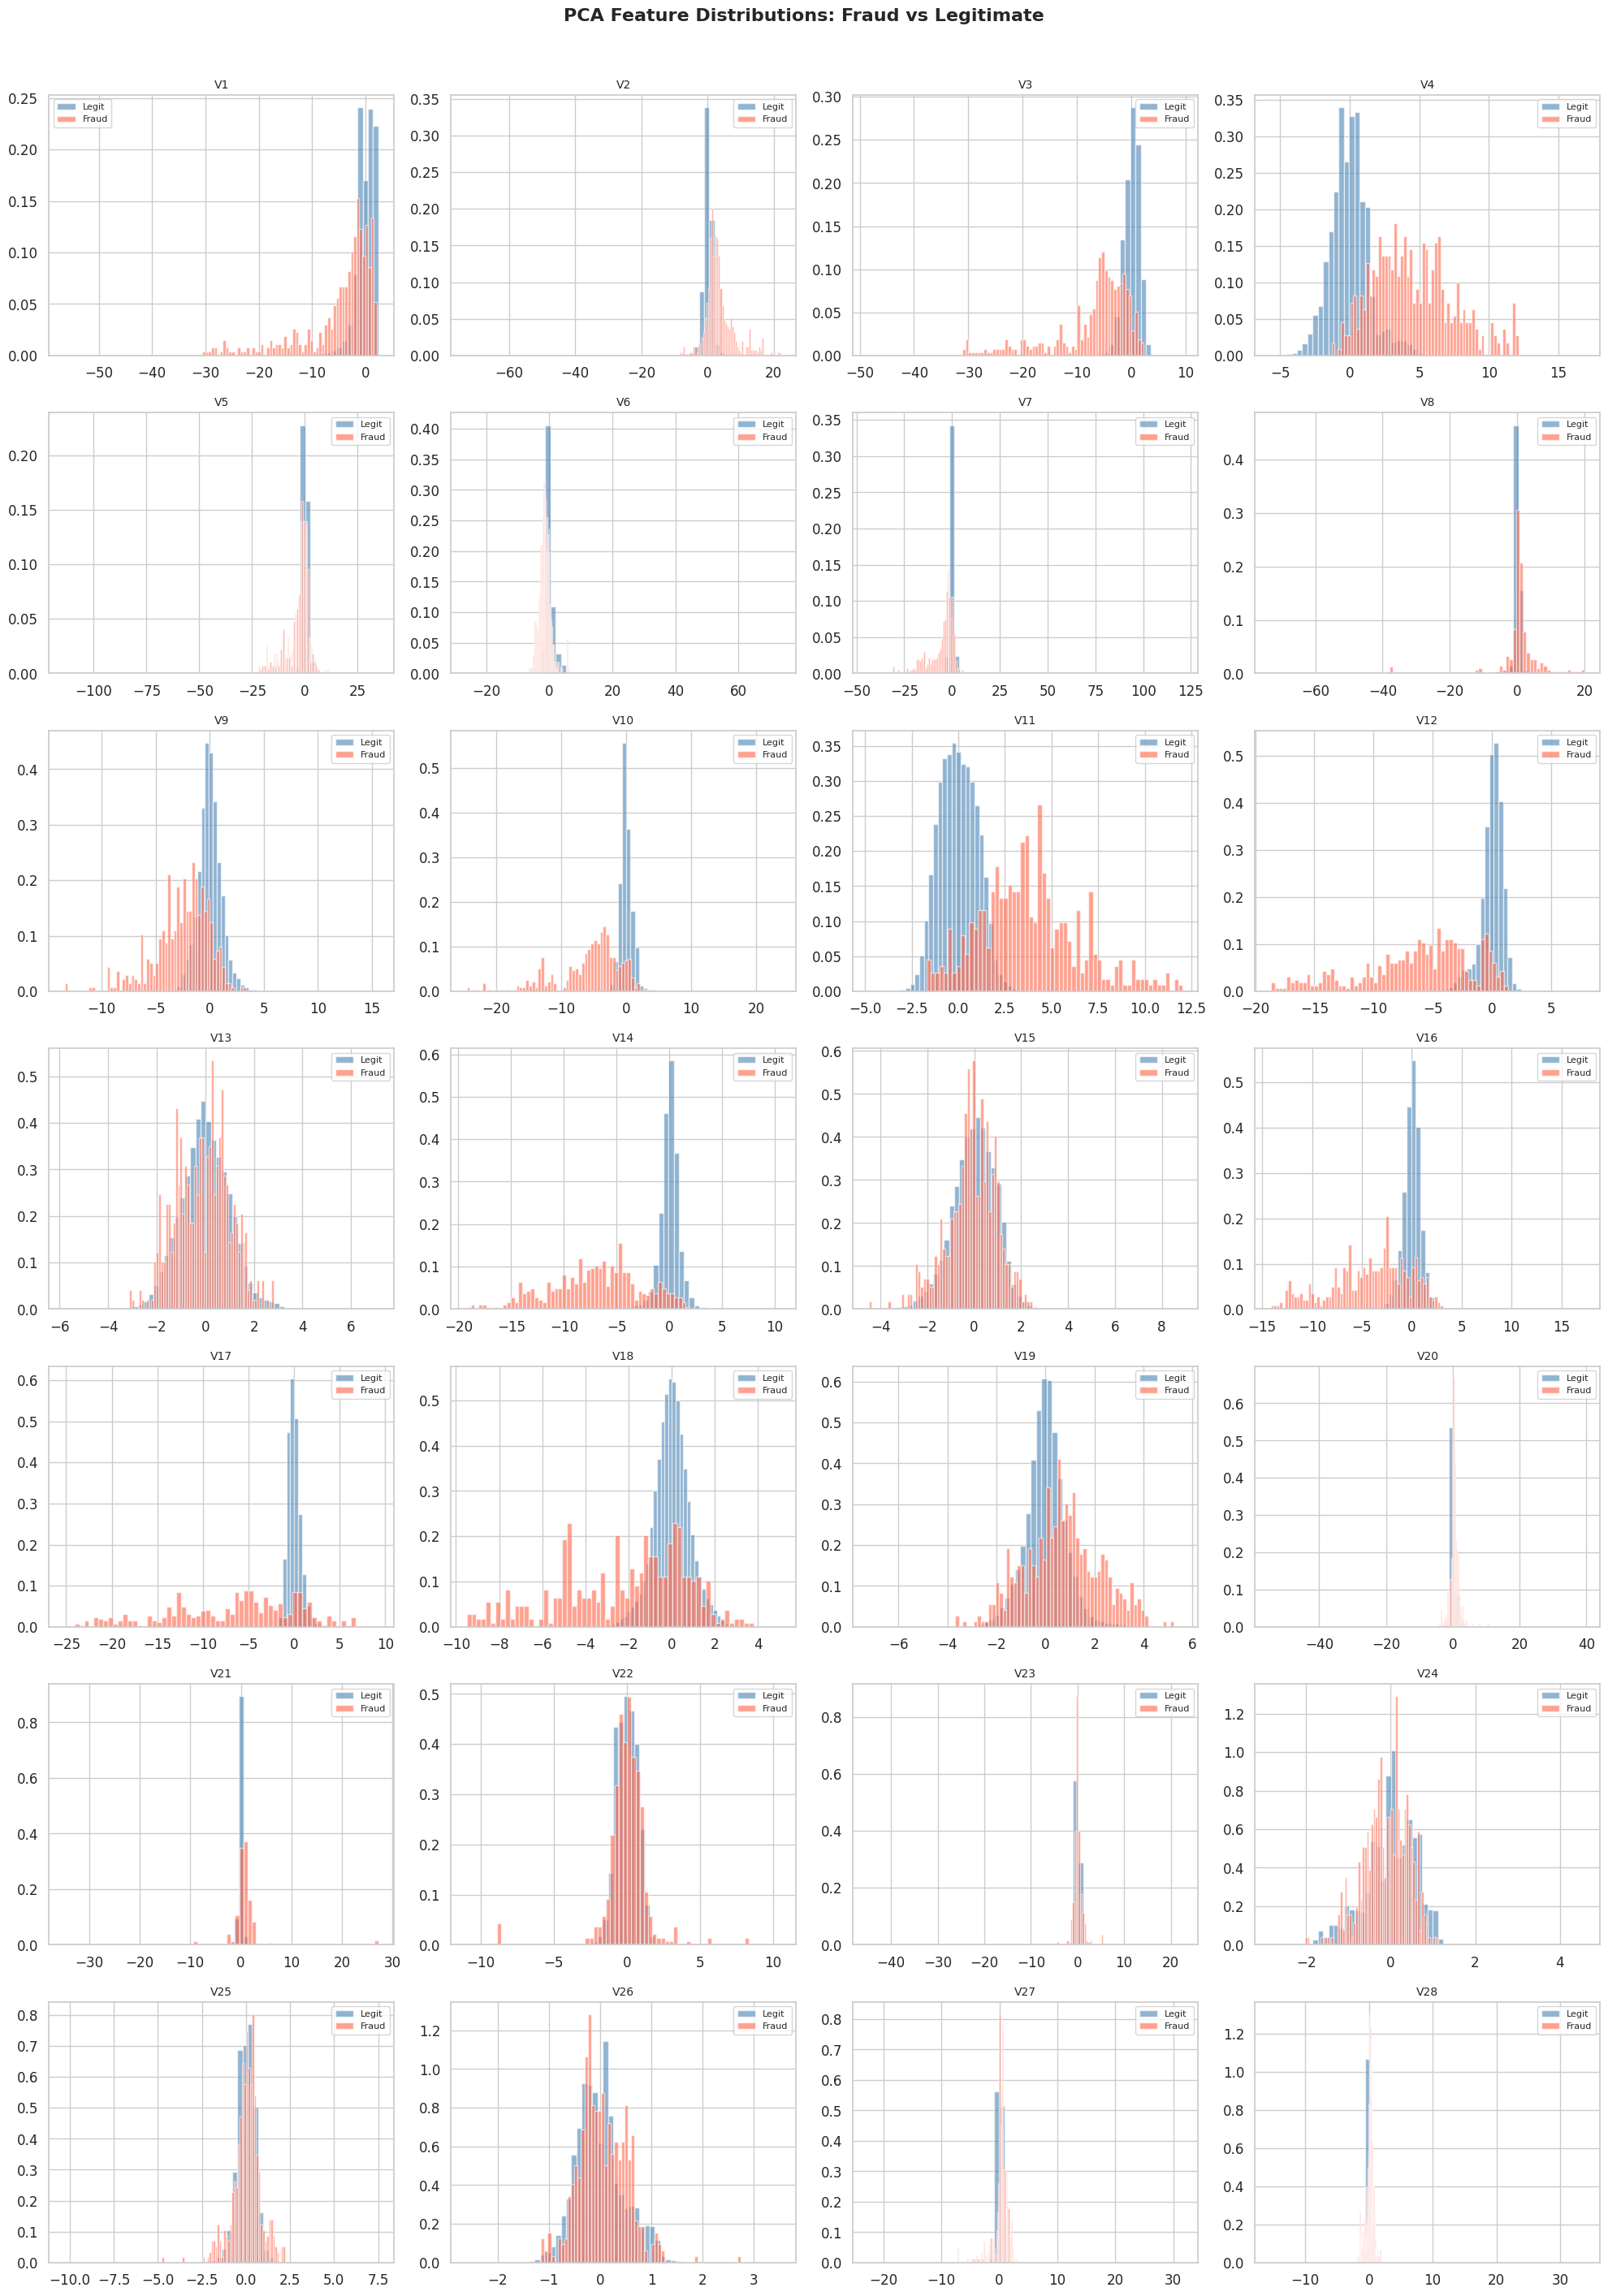

In [8]:
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    axes[i].hist(df[df['Class']==0][feat], bins=60, alpha=0.6, color='steelblue', label='Legit', density=True)
    axes[i].hist(df[df['Class']==1][feat], bins=60, alpha=0.6, color='tomato', label='Fraud', density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('PCA Feature Distributions: Fraud vs Legitimate', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'pca_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Correlation Heatmap

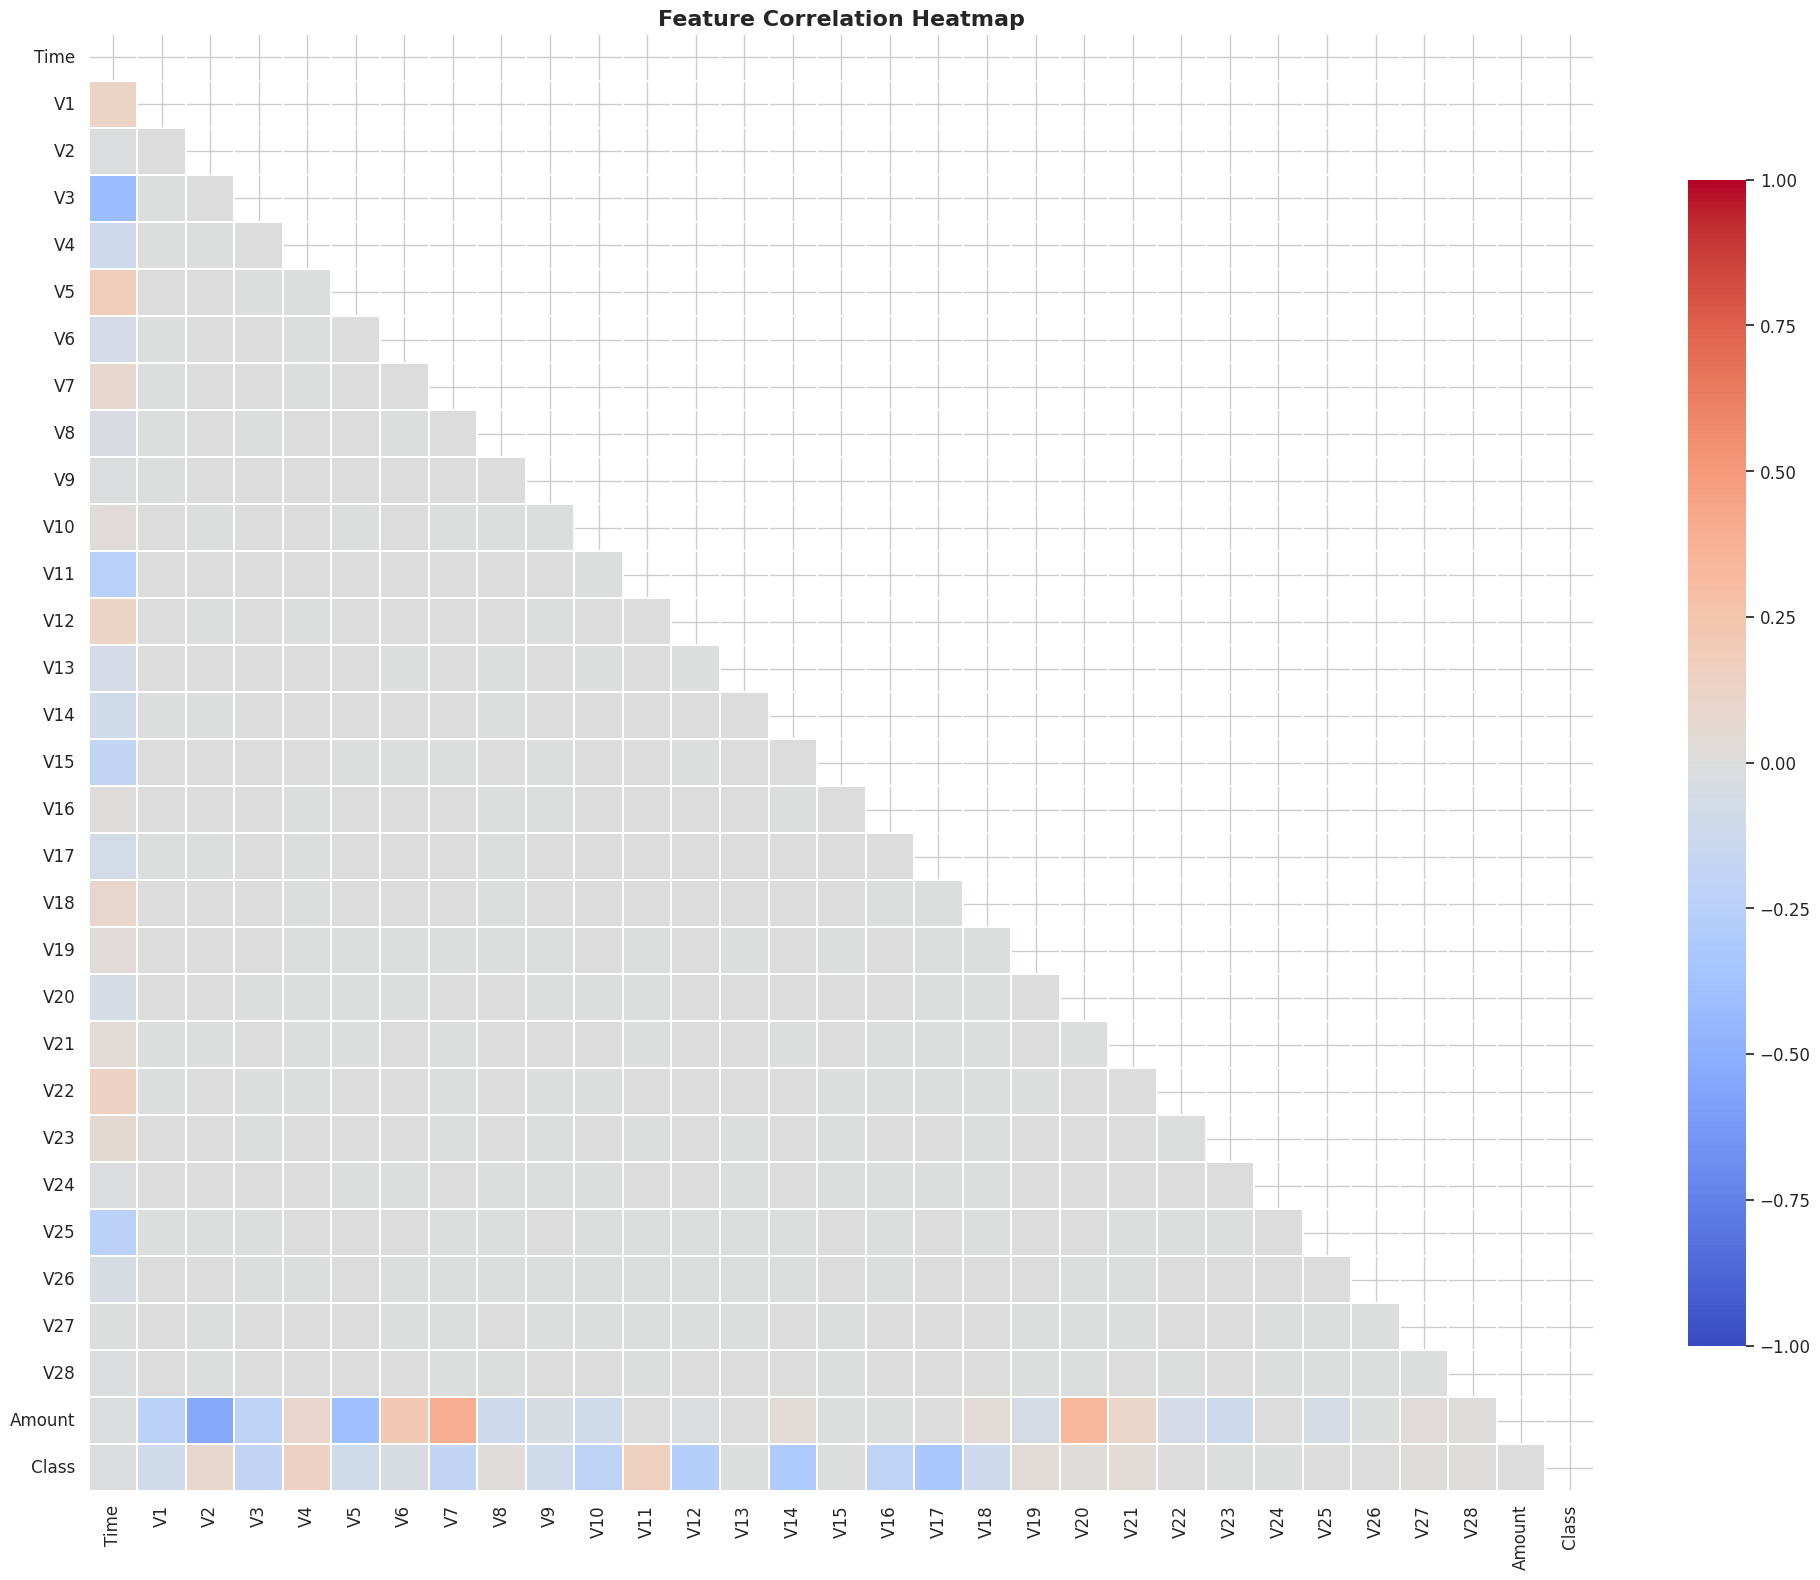


Top correlations with Class label:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
V1     0.101347
V9     0.097733
V5     0.094974
V2     0.091289
V6     0.043643
Name: Class, dtype: float64


In [9]:
plt.figure(figsize=(20, 16))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with Class
print('\nTop correlations with Class label:')
print(corr['Class'].drop('Class').abs().sort_values(ascending=False).head(15))

## 8. Boxplots — Top Discriminative Features

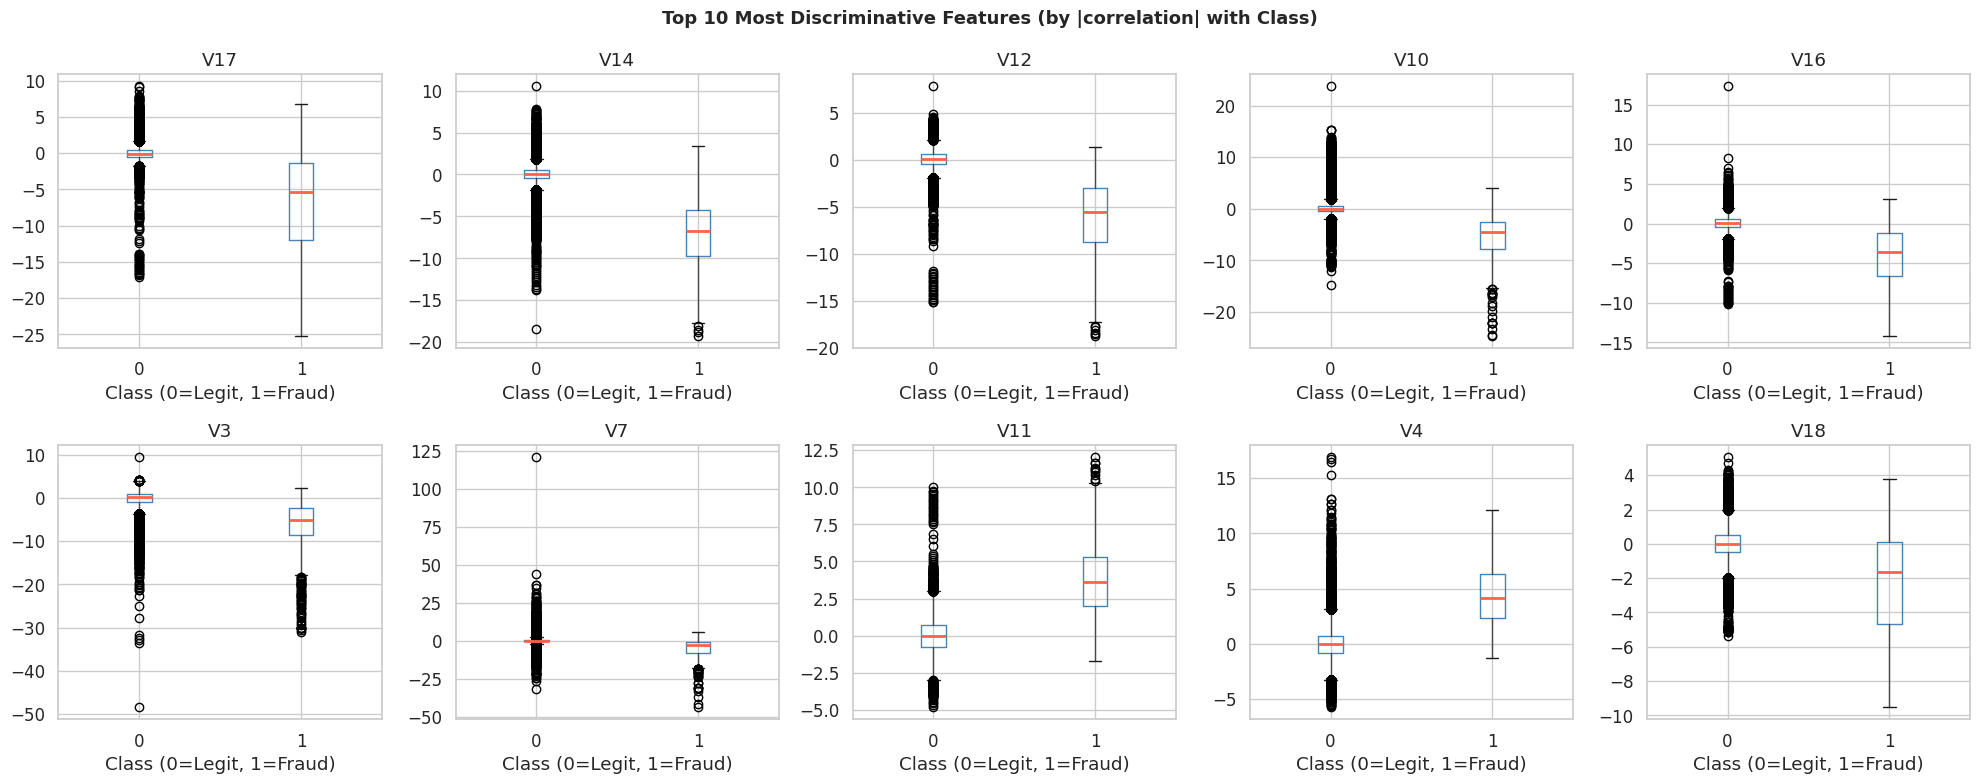

In [10]:
top_features = corr['Class'].drop('Class').abs().sort_values(ascending=False).head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    df.boxplot(column=feat, by='Class', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
    axes[i].set_title(feat)
    axes[i].set_xlabel('Class (0=Legit, 1=Fraud)')

plt.suptitle('Top 10 Most Discriminative Features (by |correlation| with Class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'top_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. EDA Summary

In [11]:
print('='*55)
print('EDA SUMMARY')
print('='*55)
print(f'Total samples     : {len(df):,}')
print(f'Features          : {df.shape[1]-1}')
print(f'Missing values    : {df.isnull().sum().sum()}')
print(f'Duplicate rows    : {df.duplicated().sum()}')
print(f'Legitimate txns   : {(df.Class==0).sum():,}  ({(df.Class==0).mean()*100:.2f}%)')
print(f'Fraud txns        : {(df.Class==1).sum():,}  ({(df.Class==1).mean()*100:.4f}%)')
print(f'Class imbalance   : ~1:577 ratio')
print(f'Amount range      : ${df.Amount.min():.2f} – ${df.Amount.max():.2f}')
print(f'Avg fraud amount  : ${df[df.Class==1].Amount.mean():.2f}')
print(f'Avg legit amount  : ${df[df.Class==0].Amount.mean():.2f}')
print('='*55)
print('PREPROCESSING NEEDS:')
print('  [x] Scale Amount and Time (not PCA-transformed)')
print('  [x] Handle severe class imbalance (SMOTE)')
print('  [x] Stratified train/test split (80/20)')
print('  [ ] No missing value imputation needed')
print('  [ ] No categorical encoding needed')
print('='*55)

EDA SUMMARY
Total samples     : 284,807
Features          : 30
Missing values    : 0


Duplicate rows    : 1081
Legitimate txns   : 284,315  (99.83%)
Fraud txns        : 492  (0.1727%)
Class imbalance   : ~1:577 ratio
Amount range      : $0.00 – $25691.16
Avg fraud amount  : $122.21
Avg legit amount  : $88.29
PREPROCESSING NEEDS:
  [x] Scale Amount and Time (not PCA-transformed)
  [x] Handle severe class imbalance (SMOTE)
  [x] Stratified train/test split (80/20)
  [ ] No missing value imputation needed
  [ ] No categorical encoding needed
